# Sentiment Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize
from leia import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\ccsra\OneDrive\Documentos\A_TESE_TUDO\PROJETO\DF.csv", sep = ';')

In [ ]:
# 1. Defina uma função para carregar o texto
def carregar_texto_do_arquivo(caminho_no_csv):
    """
    Recebe o caminho da coluna 'voto' (ex: 'PASTA_DADOS/arquivo.txt'),
    encontra o nome do arquivo (ex: 'arquivo.txt') e lê seu conteúdo.
    """
    if pd.isna(caminho_no_csv):
        return None # Retorna nulo se o caminho estiver vazio
    
    # Esta é a parte chave:
    # O CSV diz 'PASTA_DADOS/ARQUIVOTAL.txt'
    # os.path.basename() pega apenas o nome do arquivo do caminho.
    nome_arquivo = os.path.basename(caminho_no_csv)
    
    try:
        # Tenta abrir o arquivo (assumindo que ele está na mesma pasta do seu notebook)
        with open(nome_arquivo, 'r', encoding='utf-8') as f:
            texto = f.read()
        return texto # Retorna o texto completo
        
    except FileNotFoundError:
        print(f"Aviso: Arquivo '{nome_arquivo}' não encontrado. Verifique o nome.")
        return f"ERRO: Arquivo '{nome_arquivo}' não encontrado"
    except Exception as e:
        print(f"Erro ao ler '{nome_arquivo}': {e}")
        return f"ERRO: {e}"

# 2. Crie a nova coluna 'texto_completo'
print("\nIniciando o carregamento dos textos do arquivo .txt para o DataFrame...")

# Verificamos se 'voto' existe no DataFrame 'df'
if 'voto' in df.columns:
    # O método 'apply' vai executar a função 'carregar_texto_do_arquivo'
    # para CADA linha da coluna 'voto'.
    df['texto_completo'] = df['voto'].apply(carregar_texto_do_arquivo)
    
    print("Carregamento concluído!")

    # 3. Verifique o resultado
    print("\nDataFrame 'dados' agora com a coluna 'texto_completo':")
    # (O .applymap abaixo é apenas para encurtar a exibição na tela)
    print(df[['id', 'voto', 'texto_completo']].head().applymap(lambda x: str(x)[:60] + '...' if isinstance(x, str) and len(x) > 60 else x))

    print("\n--- Texto completo da primeira linha (primeiros 500 caracteres) ---")
    # É assim que você acessa o texto para a análise:
    if not df.empty and 'texto_completo' in df.columns:
        primeiro_texto = df.loc[0, 'texto_completo']
        if primeiro_texto and not primeiro_texto.startswith("ERRO"):
            # Imprime os primeiros 500 caracteres do texto carregado
            print(primeiro_texto[:500] + "\n...")
        else:
            print("Não foi possível carregar o texto da primeira linha (verifique erros acima).")
    else:
         print("DataFrame está vazio ou coluna 'texto_completo' não foi criada.")
        
else:
    print(f"\nERRO: A coluna 'voto' não foi encontrada no seu DataFrame 'dados'.")
    print("Colunas disponíveis:", df.columns.tolist())


Iniciando o carregamento dos textos do arquivo .txt para o DataFrame...
Carregamento concluído!

DataFrame 'dados' agora com a coluna 'texto_completo':
   id                         voto  \
0   1   PROJETO/AP_1025_FACHIN.txt   
1   2   PROJETO/AP_1025_MORAES.txt   
2   3  PROJETO/AP_1025_BARROSO.txt   
3   4   PROJETO/AP_1025_CARMEN.txt   
4   5   PROJETO/AP_1025_GILMAR.txt   

                                      texto_completo  
0  O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conf...  
1  O SENHOR MINISTRO ALEXANDRE DE MORAES (REVISOR...  
2  O SENHOR MINISTRO LUÍS ROBERTO BARROSO - Obrig...  
3  A SENHORA MINISTRA CÁRMEN LÚCIA -\nPresidente,...  
4  O Senhor Ministro Gilmar Mendes: Trata-se de a...  

--- Texto completo da primeira linha (primeiros 500 caracteres) ---
O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conforme
relatado, trata-se de Ação Penal deflagrada contra Fernando Affonso
Collor de Mello, Pedro Paulo Bergamaschi de Leoni Ramos e Luis Pereira
Duarte de Amorim, na qual a P

C:\Users\ccsra\AppData\Local\Temp\ipykernel_4360\1232561192.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df[['id', 'voto', 'texto_completo']].head().applymap(lambda x: str(x)[:60] + '...' if isinstance(x, str) and len(x) > 60 else x))


In [7]:
# Verificamos se 'voto' existe no DataFrame 'dados'
if 'voto' in df.columns:
    # O método 'apply' vai executar a função 'carregar_texto_do_arquivo'
    # para CADA linha da coluna 'voto'.
    df['texto_completo'] = df['voto'].apply(carregar_texto_do_arquivo)
    
    print("Carregamento concluído!")

    # 3. Verifique o resultado
    print("\nDataFrame 'dados' agora com a coluna 'texto_completo':")
    # (O .applymap abaixo é apenas para encurtar a exibição na tela)
    print(df[['id', 'voto', 'texto_completo']].head().map(lambda x: str(x)[:60] + '...' if isinstance(x, str) and len(x) > 60 else x))
      
else:
    print(f"\nERRO: A coluna 'voto' não foi encontrada no seu DataFrame 'dados'.")
    print("Colunas disponíveis:", df.columns.tolist())

    # 3. Verifique o resultado
    print("\nDataFrame 'dados' agora com a coluna 'texto_completo' (pré-visualização primeiros 100 chars):")
    # Pré-visualiza os primeiros 100 caracteres da coluna texto_completo nas primeiras linhas
    if 'texto_completo' in df.columns:
        preview = df[['id', 'voto', 'texto_completo']].head().copy()
        preview['texto_completo'] = preview['texto_completo'].apply(
            lambda x: (str(x)[:100] + '...') if isinstance(x, str) and len(x) > 100 else x
        )
        print(preview)
    else:
        print("Coluna 'texto_completo' não encontrada para pré-visualização.")

Carregamento concluído!

DataFrame 'dados' agora com a coluna 'texto_completo':
   id                         voto  \
0   1   PROJETO/AP_1025_FACHIN.txt   
1   2   PROJETO/AP_1025_MORAES.txt   
2   3  PROJETO/AP_1025_BARROSO.txt   
3   4   PROJETO/AP_1025_CARMEN.txt   
4   5   PROJETO/AP_1025_GILMAR.txt   

                                      texto_completo  
0  O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conf...  
1  O SENHOR MINISTRO ALEXANDRE DE MORAES (REVISOR...  
2  O SENHOR MINISTRO LUÍS ROBERTO BARROSO - Obrig...  
3  A SENHORA MINISTRA CÁRMEN LÚCIA -\nPresidente,...  
4  O Senhor Ministro Gilmar Mendes: Trata-se de a...  


## Verificando as primeiras linhas de cada um dos votos com o texto bruto

In [ ]:
# Itera sobre as 6 primeiras linhas do DataFrame para mostrar um resumo
for index, row in df.head(20).iterrows():
    print(f"--- Início do Voto ID: {row['id']} (Juiz: {row['juiz']}) ---")
    
    texto = row['texto_completo']
    
    # Verifica se o texto foi carregado corretamente
    if isinstance(texto, str) and not texto.startswith("ERRO"):
        # Divide o texto em linhas e pega as 6 primeiras
        primeiras_linhas = texto.split('\n')[:6]
        # Junta as linhas de volta em uma única string para exibição
        resumo_texto = '\n'.join(primeiras_linhas)
        print(resumo_texto)
        print("...\n")
    elif texto:
        # Se houver uma mensagem de erro, mostre-a
        print(texto)
        print("\n")
    else:
        # Caso o texto esteja vazio ou nulo
        print("Texto não disponível.\n")

## Verificando as últimas linhas de cada voto com o texto bruto

In [ ]:
# Itera sobre as primeiras 20 linhas do DataFrame e mostra um resumo (últimas 5 linhas de cada voto)
for index, row in df.head(20).iterrows():
    print(f"--- Final do Voto ID: {row.get('id','?')} (Juiz: {row.get('juiz','?')}) ---")
    texto = row.get('texto_completo', '')
    # Verifica se o texto foi carregado corretamente
    if isinstance(texto, str) and not texto.startswith("ERRO"):
        # Divide o texto em linhas e pega as últimas 5
        linhas = texto.split('\n')
        ultimas_linhas = linhas[-5:] if len(linhas) >= 5 else linhas
        # Junta as linhas de volta em uma única string para exibição
        resumo_texto = '\n'.join(ultimas_linhas)
        print(resumo_texto)
        print("...\n")
    elif texto:
        # Se houver uma mensagem de erro, mostre-a
        print(texto)
        print("\n")
    else:
        # Caso o texto esteja vazio ou nulo
        print("Texto não disponível.\n")

## Configurações de vizualização

In [10]:
# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Garante que os recursos do NLTK estejam baixados
def verificar_nltk():
    recursos = ['punkt', 'stopwords', 'rslp']
    for recurso in recursos:
        try:
            nltk.data.find(f'tokenizers/{recurso}') if recurso == 'punkt' else nltk.data.find(f'corpora/{recurso}') if recurso == 'stopwords' else nltk.data.find(f'stemmers/{recurso}')
        except LookupError:
            print(f"Baixando recurso NLTK: {recurso}...")
            nltk.download(recurso, quiet=True)

verificar_nltk()

## Processamento de texto e limpeza (Portugues)

In [11]:
class TextCleaner:
    """
    Responsável por todas as estratégias de limpeza de texto.
    """
    def __init__(self):
        self.stemmer = RSLPStemmer()
        self.stop_words = set(stopwords.words('portuguese'))
        
        # Stopwords específicas do contexto jurídico (ruído)
        termos_juridicos_irrelevantes = {
            'voto', 'senhor', 'ministro', 'presidente', 'excelencia', 'sessao',
            'turma', 'supremo', 'tribunal', 'federal', 'ata', 'publi', 'dj'
        }
        self.stop_words.update(termos_juridicos_irrelevantes)

    def limpeza_pesada(self, texto):
        """
        OBJETIVO: Gerar dados para modelagem de tópicos, nuvem de palavras ou clusterização.
        AÇÕES: Lowercase -> Remove Pontuação/Núm -> Remove Stopwords -> Stemming.
        """
        if not isinstance(texto, str): return ""
        
        # 1. Normalização
        texto = texto.lower()
        
        # 2. Remover caracteres especiais e números (mantém apenas letras)
        texto = re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s]', '', texto)
        
        # 3. Tokenização
        tokens = word_tokenize(texto, language='portuguese')
        
        # 4. Filtragem e Stemming
        tokens_limpos = [
            self.stemmer.stem(t) for t in tokens 
            if t not in self.stop_words and len(t) > 2
        ]
        
        return " ".join(tokens_limpos)

    def limpeza_leve_sentimento(self, texto):
        """
        OBJETIVO: Preparar texto para o LeIA (Sentiment Analysis).
        AÇÕES: Preserva pontuação (!?), acentuação e estrutura de frases. Remove apenas sujeira de formatação.
        """
        if not isinstance(texto, str): return ""
        
        # Remove quebras de linha excessivas e espaços múltiplos
        texto = re.sub(r'\s+', ' ', texto).strip()
        return texto

## Aplicando a limpeza para Análise de Sentimentos

In [12]:
# Instancia o limpador de texto
cleaner = TextCleaner()

# Aplica a limpeza leve (para análise de sentimento) na coluna 'texto_completo'
# e armazena o resultado em uma nova coluna.
df['texto_limpo_sentimento'] = df['texto_completo'].apply(cleaner.limpeza_leve_sentimento)

# Verificando as primeiras linhas para garantir que a limpeza foi aplicada
import textwrap

def visualizar_texto_limpo(df, n_linhas=6, wrap_width=100, max_wrapped_lines=6):
    print("--- VISUALIZAÇÃO ---\n")
    for _, row in df.head(n_linhas).iterrows():
        id_voto = row.get('id', '')
        juiz = row.get('juiz', '')
        texto = row.get('texto_limpo_sentimento', '') or ''
        print("="*80)
        print(f"ID: {id_voto} | Juiz: {juiz}")
        print("-"*80)
        if not texto.strip():
            print("⚠️  Texto vazio ou não processado corretamente\n")
            continue

        # Quebra o texto limpo em linhas visíveis
        wrapped = textwrap.wrap(texto, width=wrap_width)
        for i, linha in enumerate(wrapped[:max_wrapped_lines], start=1):
            print(f"{i}. {linha}")
        if len(wrapped) > max_wrapped_lines:
            print(f"... (+{len(wrapped) - max_wrapped_lines} linhas adicionais)")

        # Mostra também um preview contínuo (útil para confirmar limpeza)
        preview_chars = 300
        preview = texto[:preview_chars] + ("..." if len(texto) > preview_chars else "")
        print("\n--- Preview contínuo (primeiros %d chars) ---" % preview_chars)
        print(preview)
        print("\n")

# Chama a função
visualizar_texto_limpo(df, n_linhas=6, wrap_width=100, max_wrapped_lines=6)

--- VISUALIZAÇÃO ---

ID: 1 | Juiz: Fachin
--------------------------------------------------------------------------------
1. O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conforme relatado, trata-se de Ação Penal deflagrada
2. contra Fernando Affonso Collor de Mello, Pedro Paulo Bergamaschi de Leoni Ramos e Luis Pereira
3. Duarte de Amorim, na qual a Procuradoria-Geral da República lhes atribui a prática de crimes de
4. corrupção passiva, lavagem de dinheiro e organização criminosa. Segundo o Ministério Público
5. Federal, entre os anos de 2010 e 2014, identificou-se a atuação de complexa organização criminosa na
6. Petrobras Distribuidora S/A - BR Distribuidora S/A, sobre a qual exerciam decisiva influência
... (+1889 linhas adicionais)

--- Preview contínuo (primeiros 300 chars) ---
O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conforme relatado, trata-se de Ação Penal deflagrada contra Fernando Affonso Collor de Mello, Pedro Paulo Bergamaschi de Leoni Ramos e Luis Pereira Duarte de Amorim

## Analisador de Sentimentos

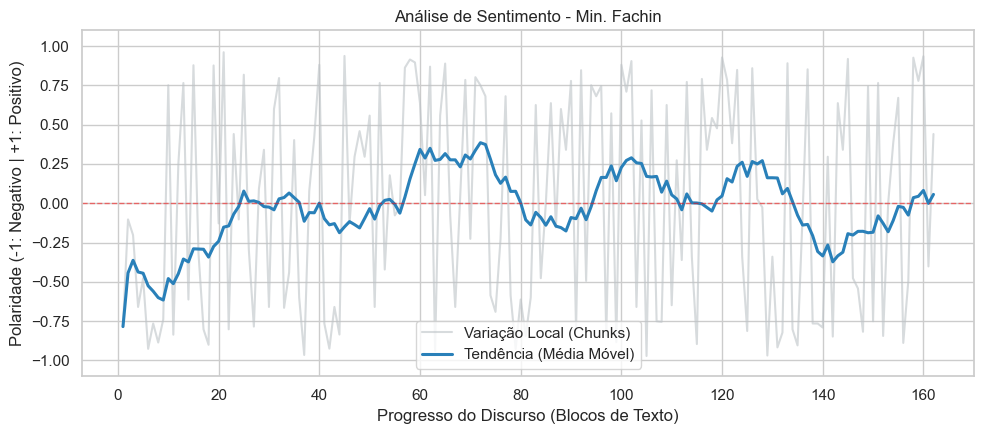

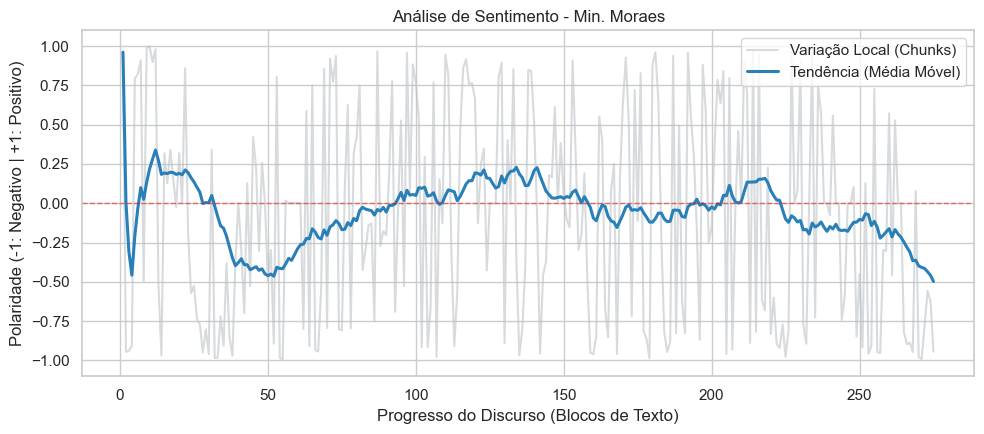

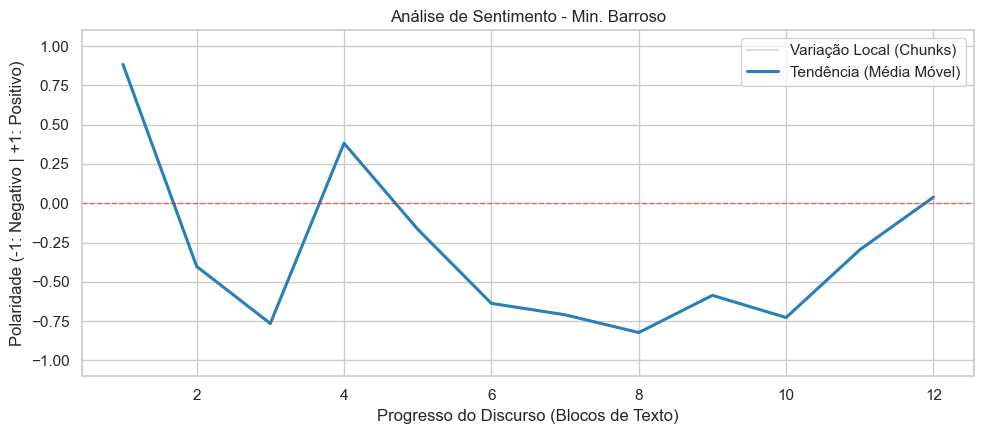

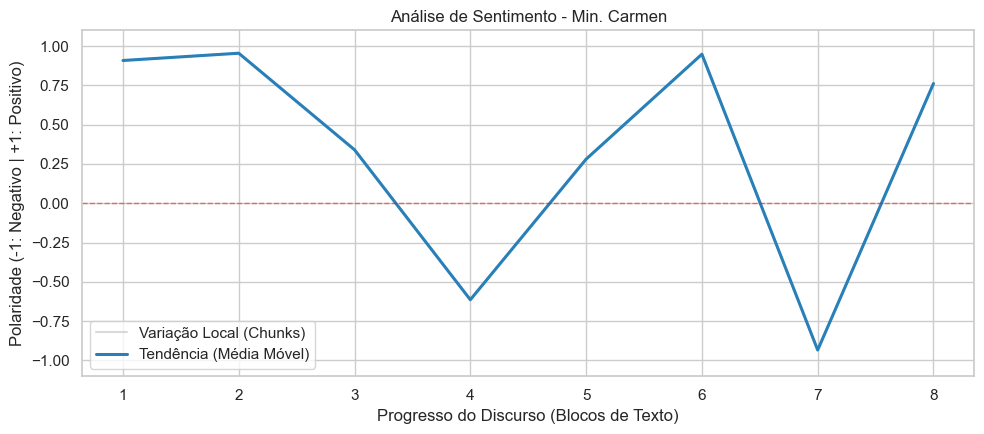

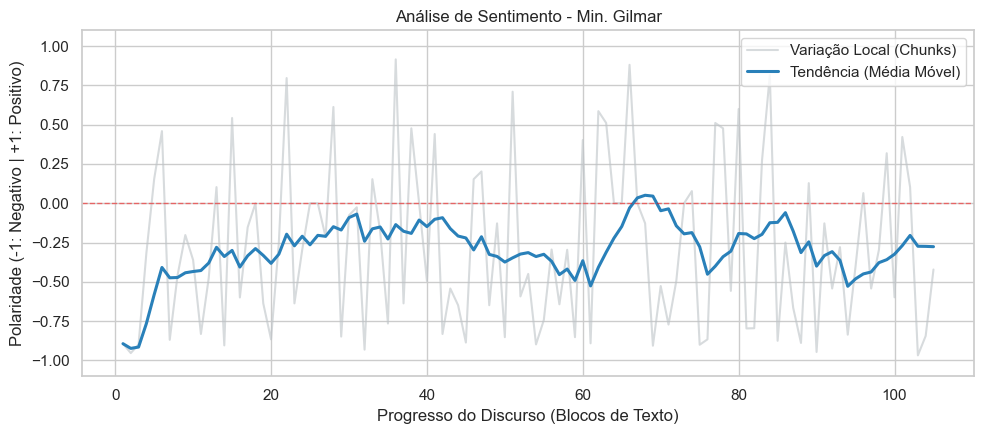

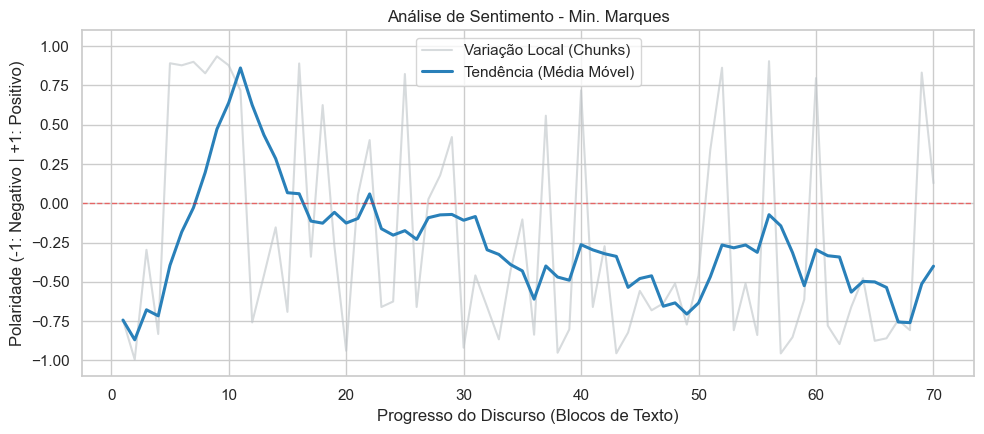

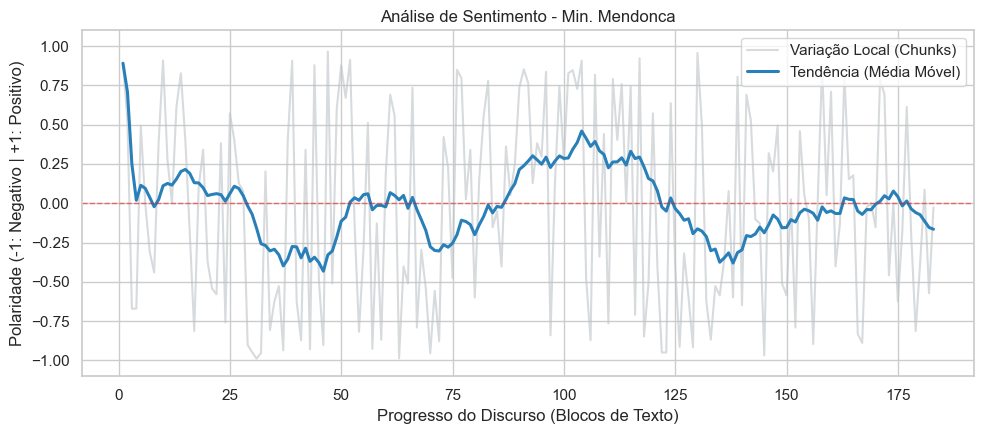

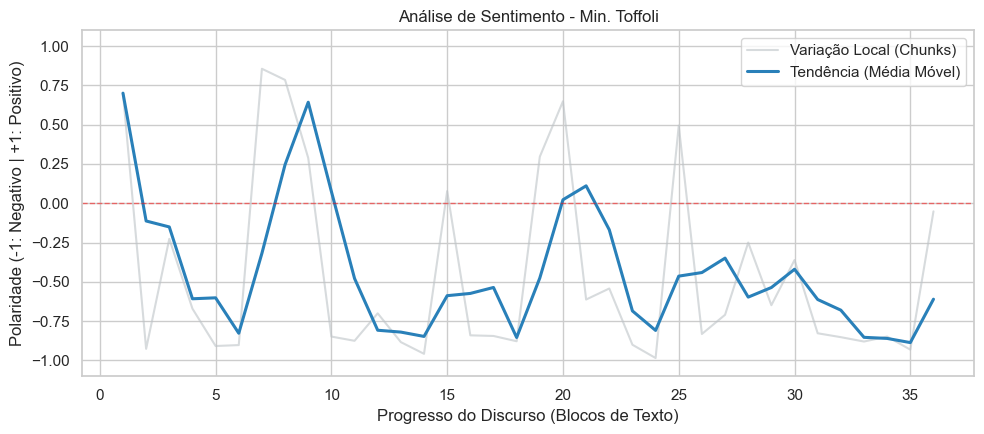

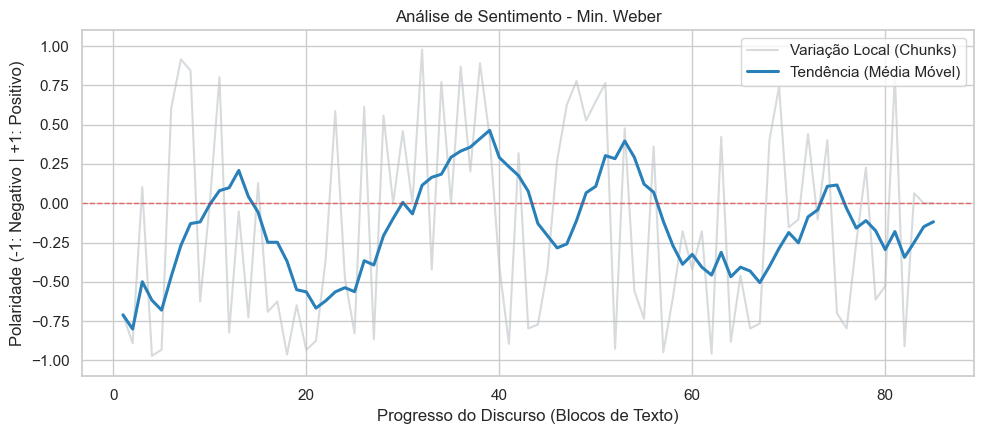

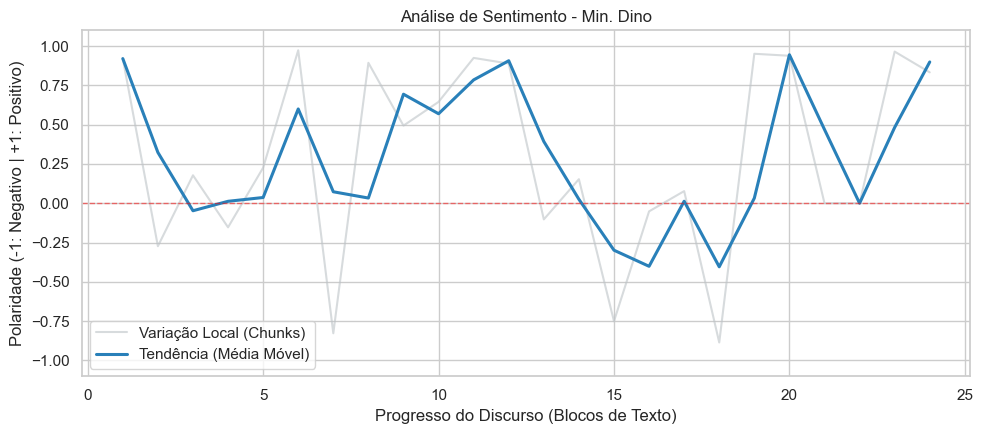

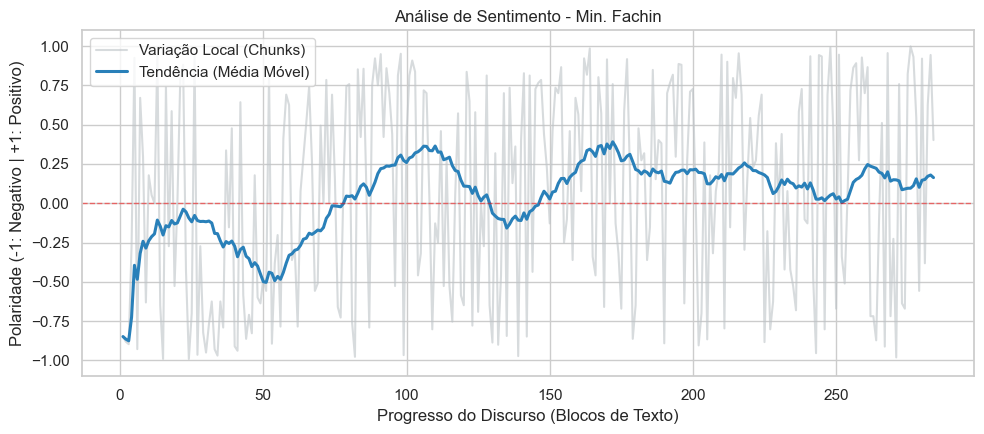

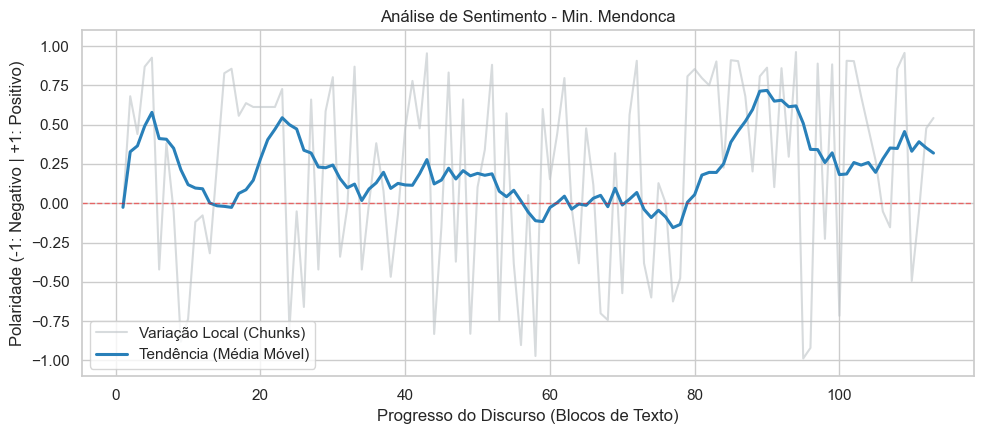

In [17]:
class SentimentAnalyzer:
    """
    Gerencia a análise de sentimentos e geração de gráficos.
    """
    def __init__(self):
        self.analyzer = SentimentIntensityAnalyzer()

# Função para analisar a evolução dos sentimentos dos votos
    def analisar_evolucao(self, texto, tamanho_chunk=3):
        """
        Divide o texto em blocos de sentenças e calcula o sentimento de cada bloco.
        """
        # Divide por sentenças (ponto final seguido de espaço e letra maiúscula ou fim de string)
        sentencas = re.split(r'(?<=[.!?])\s+(?=[A-Z])', texto)

        # Agrupa sentenças em chunks
        chunks = [" ".join(sentencas[i:i + tamanho_chunk]) for i in range(0, len(sentencas), tamanho_chunk)]

        scores = []
        for chunk in chunks:
            if len(chunk) > 10: # Ignora pedaços muito pequenos
                # 'compound' é a métrica normalizada [-1 a 1]
                score = self.analyzer.polarity_scores(chunk)['compound']
                scores.append(score)

        media_global = np.mean(scores) if scores else 0.0
        return media_global, scores

    def gerar_grafico(self, timeline, nome_juiz=None, caso=None, show=False, save=False, out_dir='graficos_output'):
        """Plota a evolução do sentimento para um único voto."""
        # Normaliza timeline para lista de floats
        if timeline is None:
            return None
        # Se a timeline veio como string (ex: leitura CSV), tentar converter
        if isinstance(timeline, str):
            try:
                import ast
                timeline = ast.literal_eval(timeline)
            except Exception:
                try:
                    timeline = [float(x.strip()) for x in timeline.split(',') if x.strip()!='']
                except Exception:
                    return None
        try:
            timeline_vals = [float(x) for x in timeline]
        except Exception:
            timeline_vals = []
            for x in timeline:
                try:
                    timeline_vals.append(float(x))
                except Exception:
                    continue
        if not timeline_vals:
            return None
        # Trata juiz/caso
        nome_juiz = str(nome_juiz or '')
        caso_val = '' if caso is None else str(caso).strip()
        if caso_val.lower() in ('nan','none'):
            caso_val = ''
        # Safe names para salvar arquivo
        safe_juiz = re.sub(r'[^\w\-_\. ]', '_', nome_juiz).strip().replace(' ', '_')
        safe_caso = re.sub(r'[^\w\-_\. ]', '_', caso_val).strip().replace(' ', '_')
        # Cria figura
        fig, ax = plt.subplots(figsize=(10, 4.5))
        x = list(range(1, len(timeline_vals) + 1))
        ax.plot(x, timeline_vals, color='#bdc3c7', alpha=0.6, label='Variação Local (Chunks)')
        window = max(1, len(timeline_vals) // 10)
        rolling_mean = pd.Series(timeline_vals).rolling(window=window, min_periods=1).mean()
        ax.plot(x, rolling_mean, color='#2980b9', linewidth=2.2, label='Tendência (Média Móvel)')
        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        titulo = f"Análise de Sentimento - Min. {nome_juiz}"
        if caso_val:
            titulo += f" ({caso_val})"
        ax.set_title(titulo)
        ax.set_xlabel("Progresso do Discurso (Blocos de Texto)")
        ax.set_ylabel("Polaridade (-1: Negativo | +1: Positivo)")
        ax.set_ylim(-1.1, 1.1)
        ax.legend()
        fig.tight_layout()
        if show:
            from IPython.display import display
            display(fig)
        if save:
            os.makedirs(out_dir, exist_ok=True)
            filename = os.path.join(out_dir, f"caso_{safe_caso}_{safe_juiz}.png")
            fig.savefig(filename, dpi=100, bbox_inches='tight')
        plt.close(fig)


from IPython.display import display
%matplotlib inline

from IPython.display import display
import ast

def plot_sentiment_timelines(df, show=True, save=False, out_dir='graficos_output'):
    os.makedirs(out_dir, exist_ok=True)

    for idx, row in df.iterrows():
        timeline = row.get('timeline_chunks', None)
        if timeline is None:
            continue

        # Se a timeline foi armazenada como string (por ex. ao ler CSV), tenta converter para lista
        if isinstance(timeline, str):
            try:
                timeline = ast.literal_eval(timeline)
            except Exception:
                # tenta separar por vírgula como fallback
                try:
                    timeline = [float(x.strip()) for x in timeline.split(',') if x.strip()!='']
                except Exception:
                    continue

        # Garante lista de floats
        try:
            timeline_vals = [float(x) for x in timeline]
        except Exception:
            # ignora entradas inválidas
            timeline_vals = []
            for x in timeline:
                try:
                    timeline_vals.append(float(x))
                except Exception:
                    continue

        if not timeline_vals:
            continue

        nome_juiz = str(row.get('juiz', '') or '').strip()
        # Trata corretamente valores ausentes ou 'nan' na coluna 'caso'
        raw_caso = row.get('caso', '')
        if pd.isna(raw_caso):
            caso_val = ''
        else:
            caso_val = str(raw_caso).strip()
        if caso_val.lower() in ('nan', 'none'):
            caso_val = ''

        # Versões 'seguras' para salvar arquivos (mantidas por segurança)
        safe_juiz = re.sub(r'[^\w\-_\. ]', '_', nome_juiz).strip().replace(' ', '_')
        safe_caso = re.sub(r'[^\w\-_\. ]', '_', caso_val).strip().replace(' ', '_')

        fig, ax = plt.subplots(figsize=(10, 4.5))
        x = list(range(1, len(timeline_vals) + 1))

        ax.plot(x, timeline_vals, color='#bdc3c7', alpha=0.6, label='Variação Local (Chunks)')

        window = max(1, len(timeline_vals) // 10)
        rolling_mean = pd.Series(timeline_vals).rolling(window=window, min_periods=1).mean()
        ax.plot(x, rolling_mean, color='#2980b9', linewidth=2.2, label='Tendência (Média Móvel)')

        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        titulo = f"Análise de Sentimento - Min. {nome_juiz}"
        if caso_val:
            titulo += f" ({caso_val})"
        ax.set_title(titulo)
        ax.set_xlabel("Progresso do Discurso (Blocos de Texto)")
        ax.set_ylabel("Polaridade (-1: Negativo | +1: Positivo)")
        ax.set_ylim(-1.1, 1.1)
        ax.legend()
        fig.tight_layout()

        if show:
            display(fig)
        if save:
            filename = os.path.join(out_dir, f"caso_{safe_caso}_{safe_juiz}.png")
            fig.savefig(filename, dpi=100, bbox_inches='tight')

        plt.close(fig)

# Executa: exibe inline e não salva por padrão
plot_sentiment_timelines(df, show=True, save=False)


Gerando e exibindo gráficos para cada voto...


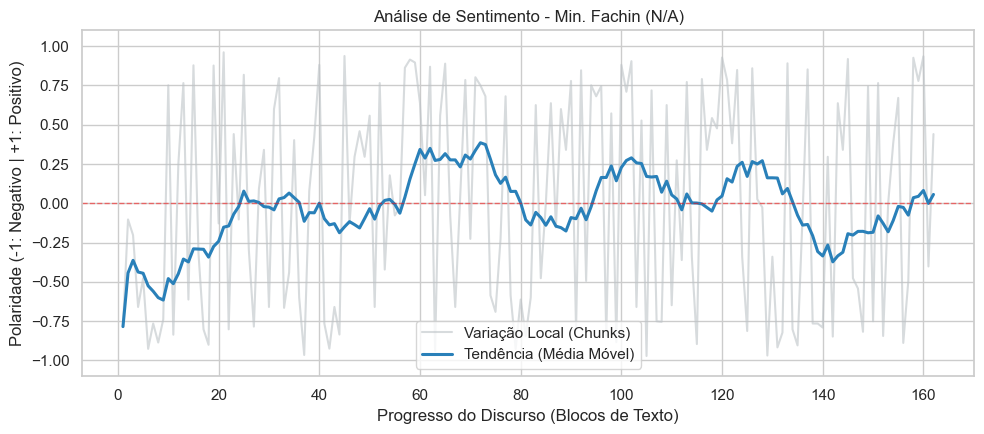

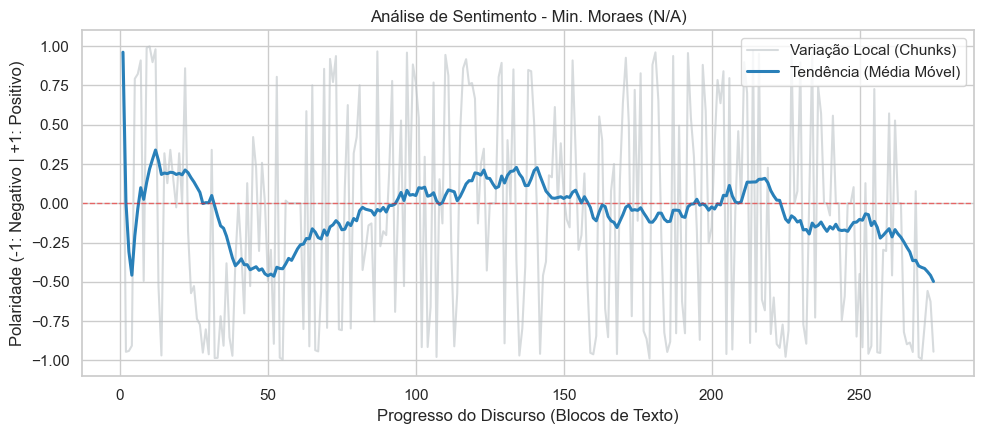

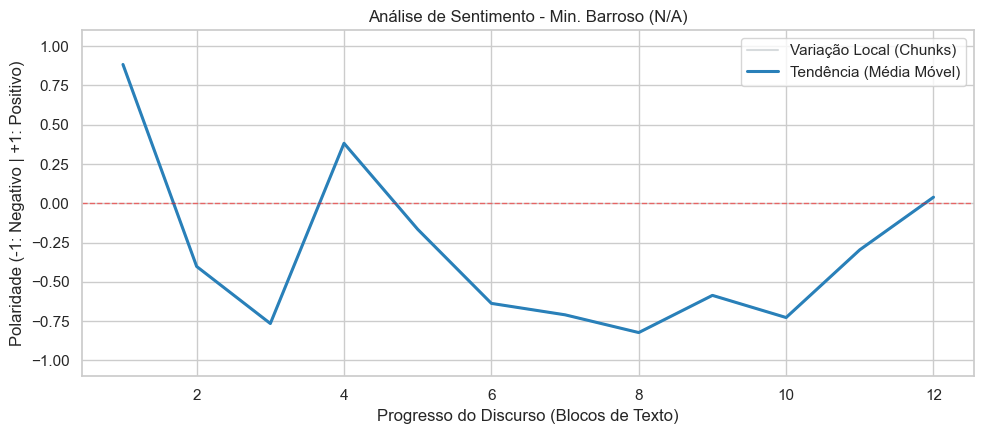

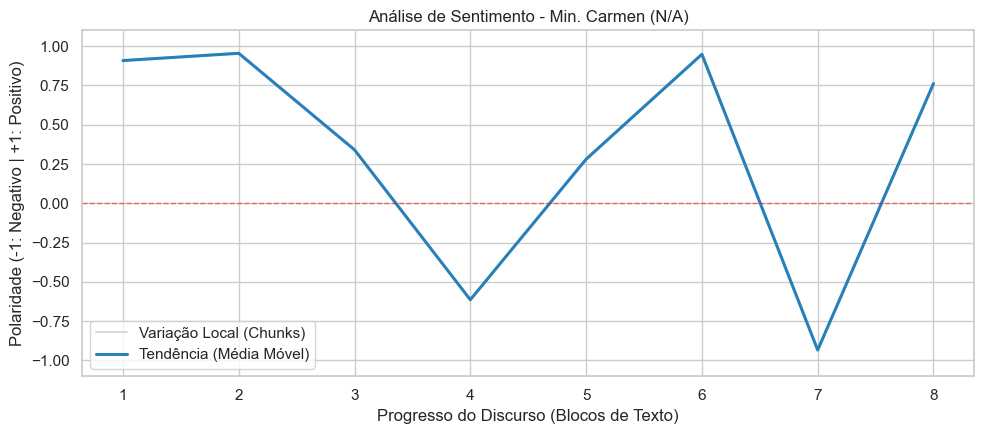

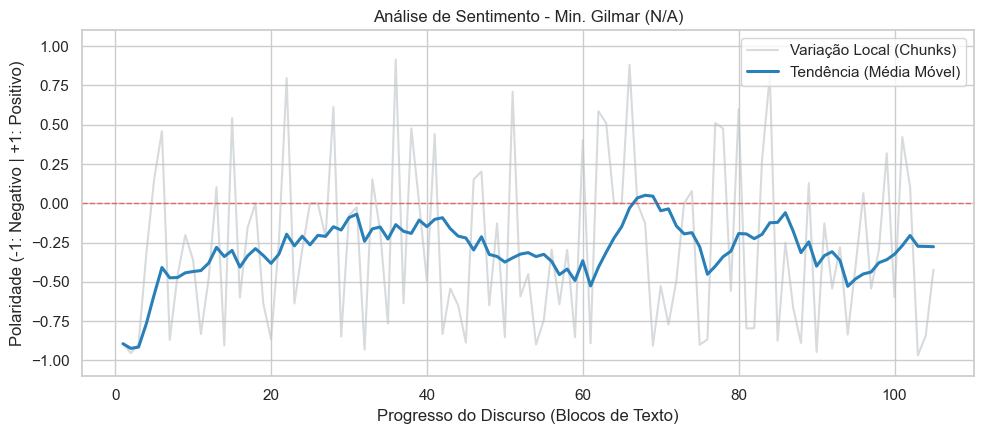

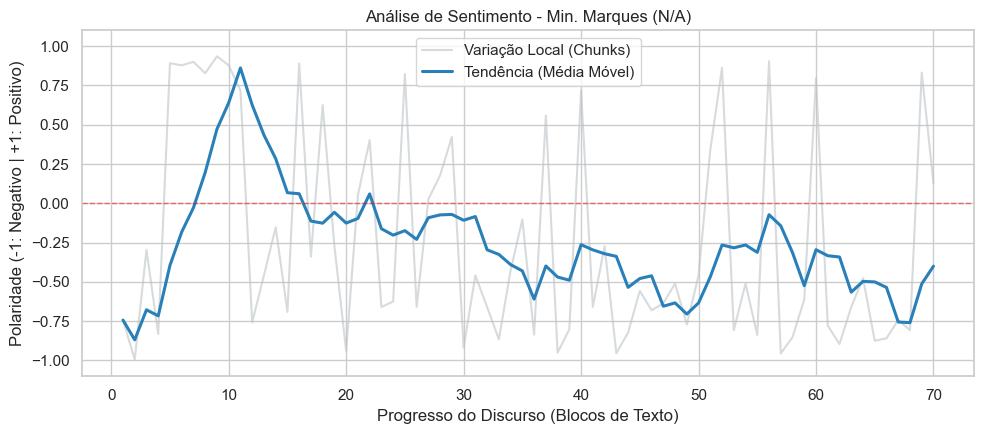

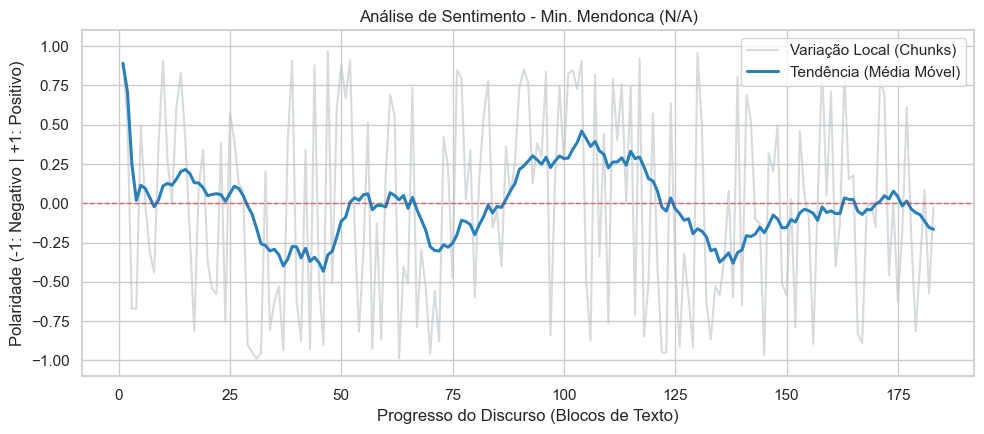

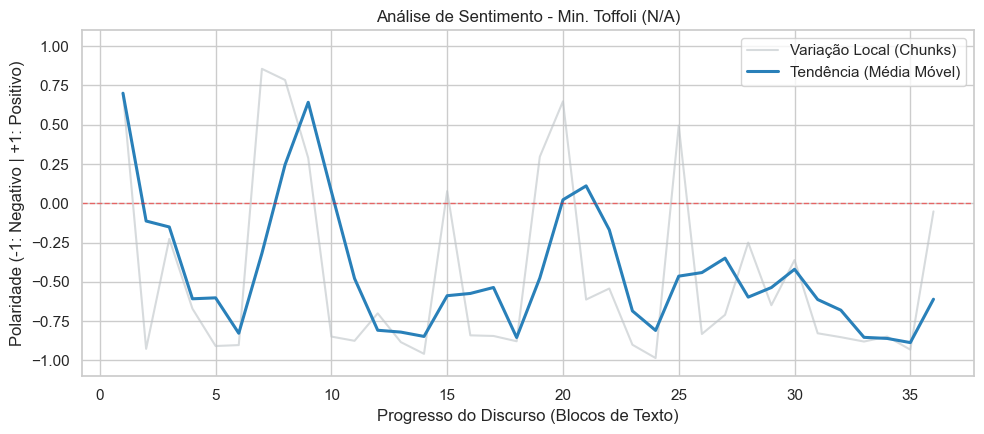

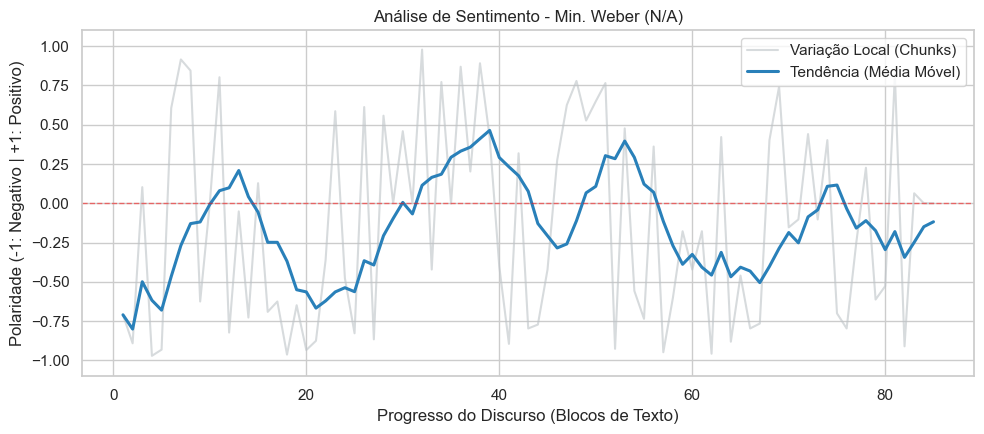

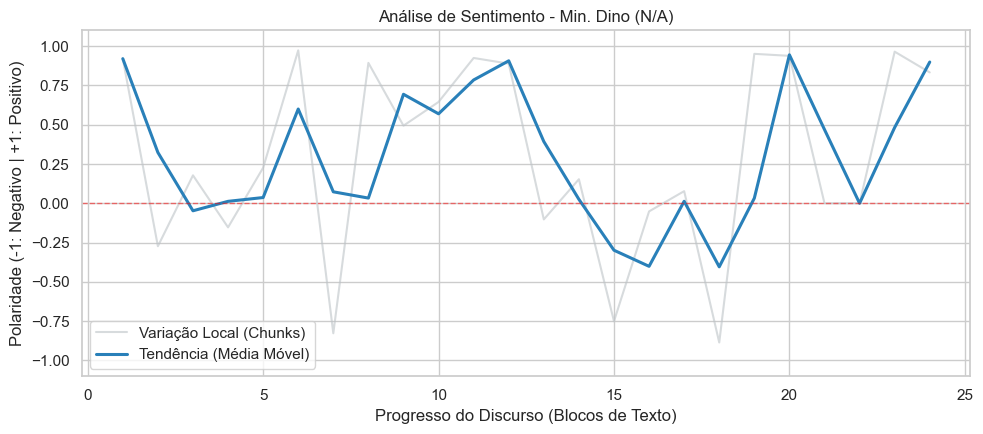

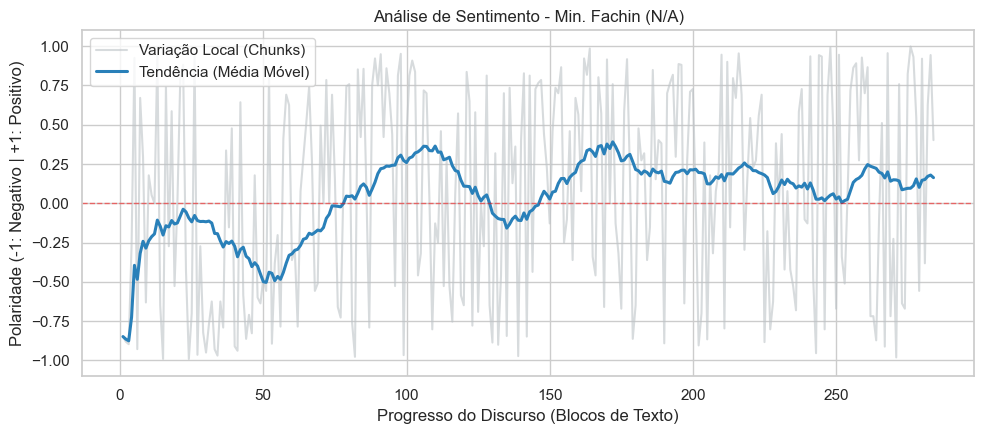

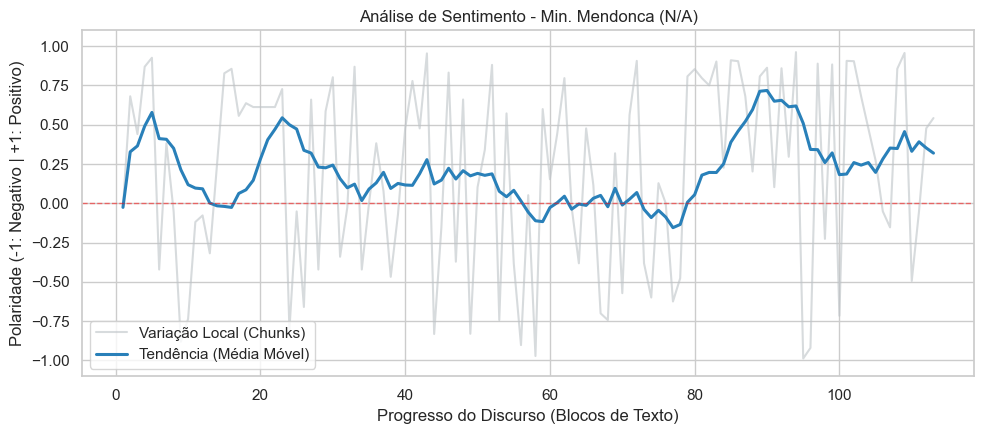

Processo concluído. Gráficos exibidos acima.


In [18]:
# Instancia o analisador de sentimentos
analyzer = SentimentAnalyzer()

print("Gerando e exibindo gráficos para cada voto...")

# Itera sobre o DataFrame para gerar um gráfico por voto
# Os gráficos serão exibidos inline
for index, row in df.iterrows():
    timeline = row.get('timeline_chunks')
    
    # Gera o gráfico apenas se houver dados de sentimento (timeline)
    if timeline and len(timeline) > 0:
        analyzer.gerar_grafico(
            timeline=timeline,
            nome_juiz=row.get('juiz', 'N/A'),
            caso=row.get('caso', 'N/A'),
            show=True  # Garante que os gráficos sejam exibidos e não salvos
        )

print(f"Processo concluído. Gráficos exibidos acima.")

## Aplicando a Análise de Sentimentos

In [16]:
# 1) Aplica analisar_evolucao() em 'texto_limpo_sentimento' e salva média + timeline
analyzer = SentimentAnalyzer()

medias = []
timelines = []

for idx, row in df.iterrows():
    texto = row.get('texto_limpo_sentimento', '') or ''
    if isinstance(texto, str) and texto.strip():
        media, timeline = analyzer.analisar_evolucao(texto)
        medias.append(media)
        timelines.append(timeline)
    else:
        medias.append(np.nan)
        timelines.append([])

df['score_media'] = medias
df['timeline_chunks'] = timelines

print("Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.")


# Gera uma pré-visualização curta dos primeiros 5 chunks para evitar saída muito grande
timeline_preview = [tl[:5] if isinstance(tl, list) else [] for tl in timelines]
# Converte a pré-visualização em string curta para exibição segura
timeline_preview_str = [(", ".join([f"{s:.2f}" if isinstance(s, float) else str(s) for s in tl]) + (f" ...(+{len(tl)-5})" if len(tl) > 5 else "")) if tl else "" for tl in timeline_preview]
timeline_len = [len(tl) if isinstance(tl, list) else 0 for tl in timelines]

df['timeline_preview'] = timeline_preview_str
df['timeline_len'] = timeline_len

# Mostra apenas as colunas geradas para verificação (primeiras 10 linhas)
print("Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.")
print("Abaixo uma verificação resumida (id, juiz, score_media, timeline_len, timeline_preview):\n")
print(df[['id', 'juiz', 'score_media', 'timeline_len', 'timeline_preview']].head(10).to_string(index=False))

Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.
Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.
Abaixo uma verificação resumida (id, juiz, score_media, timeline_len, timeline_preview):

 id     juiz  score_media  timeline_len                  timeline_preview
  1   Fachin     0.002681           162 -0.78, -0.10, -0.20, -0.66, -0.48
  2   Moraes    -0.085601           275   0.96, -0.95, -0.94, -0.91, 0.79
  3  Barroso    -0.317208            12   0.88, -0.40, -0.77, 0.38, -0.17
  4   Carmen     0.330638             8     0.91, 0.95, 0.34, -0.61, 0.28
  5   Gilmar    -0.279161           105  -0.89, -0.95, -0.90, -0.32, 0.15
  6  Marques    -0.240817            70  -0.74, -0.99, -0.30, -0.83, 0.89
  7 Mendonca    -0.031405           183    0.89, 0.53, -0.67, -0.67, 0.49
  8  Toffoli    -0.459619            36  0.70, -0.93, -0.23, -0.67, -0.91
  9    Weber    -0.132065            85  -0.71, -0.89, 0.10, -0.97, -0.93
 10     Dino     0